In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [2]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    "../dataset/raw_images",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    "../dataset/raw_images",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 458 images belonging to 7 classes.
Found 112 images belonging to 7 classes.


In [5]:
print("Class indices:", train_generator.class_indices)

Class indices: {'iron_deficiency': 0, 'normal': 1, 'vitamin_a': 2, 'vitamin_b': 3, 'vitamin_c': 4, 'vitamin_d': 5, 'vitamin_e': 6}


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(train_generator.num_classes, activation='softmax')
])

C:\Users\gunag\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,471 (84.86 MB)

 Trainable params: 22,246,471 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 40

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.1965 - loss: 2.1708 - val_accuracy: 0.1786 - val_loss: 1.8383
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 717ms/step - accuracy: 0.2860 - loss: 1.6865 - val_accuracy: 0.3214 - val_loss: 1.8756
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 636ms/step - accuracy: 0.3996 - loss: 1.4665 - val_accuracy: 0.4821 - val_loss: 1.9370
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 592ms/step - accuracy: 0.4432 - loss: 1.3357 - val_accuracy: 0.4018 - val_loss: 2.1829
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 683ms/step - accuracy: 0.4083 - loss: 1.3451 - val_accuracy: 0.4107 - val_loss: 3.4051
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 799ms/step - accuracy: 0.4629 - loss: 1.2630 - val_accuracy: 0.3929 - val_loss: 2.9581
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 629ms/step - accuracy: 0.4236 - loss: 1.3251 - val_accuracy: 0.4107 - val_loss: 2.8562
Epoch 8/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 615ms/step - accuracy: 0.4978 - loss: 1.2370 - val_accurac

In [9]:
model.save("../models/trained_model.h5")

print("Model saved successfully")

Model saved successfully


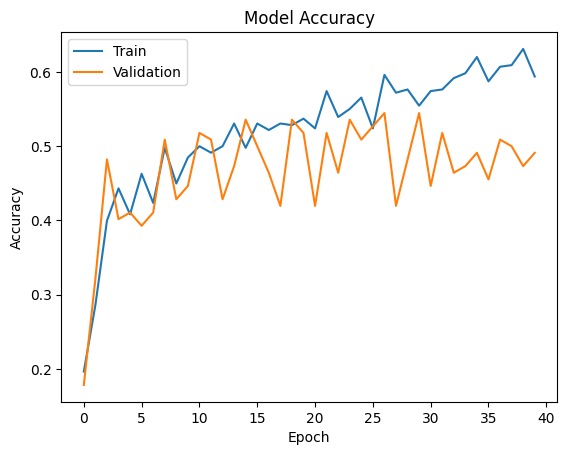

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [11]:
print(train_generator.class_indices)

{'iron_deficiency': 0, 'normal': 1, 'vitamin_a': 2, 'vitamin_b': 3, 'vitamin_c': 4, 'vitamin_d': 5, 'vitamin_e': 6}


In [12]:
# Evaluate model

loss, accuracy = model.evaluate(val_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 395ms/step - accuracy: 0.4643 - loss: 5.7845
Validation Loss: 5.7844977378845215
Validation Accuracy: 0.4642857015132904


In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [14]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 398ms/step


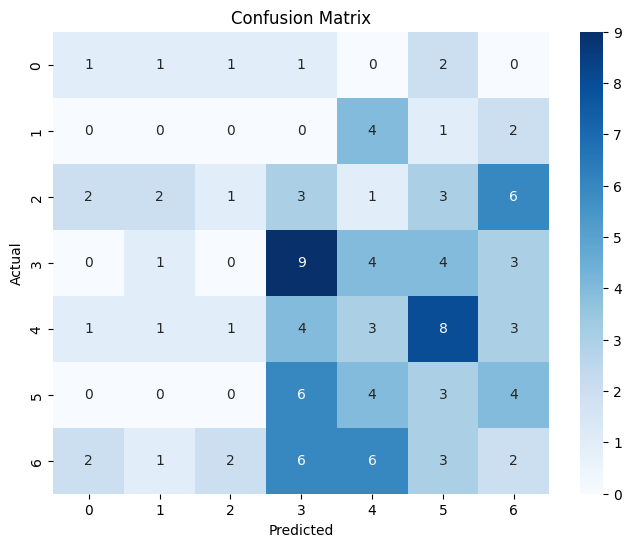

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

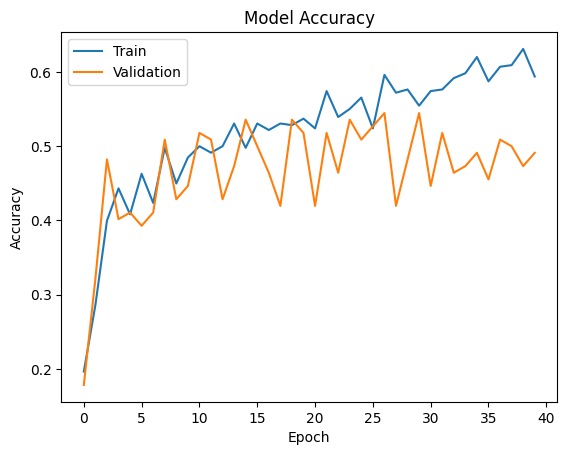

In [17]:
# Plot accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train', 'Validation'])

plt.show()

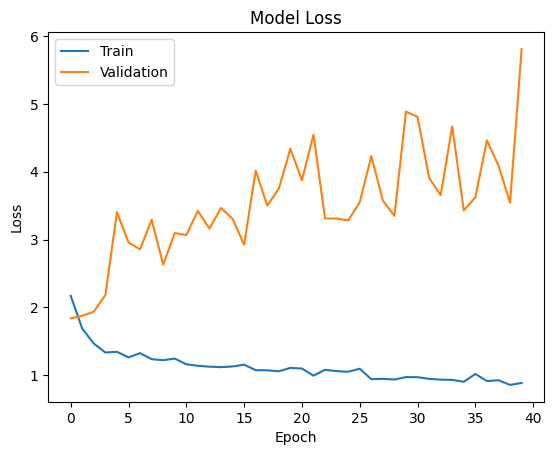

In [18]:
# Plot loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(['Train', 'Validation'])

plt.show()